In [1]:
import pickle
import argparse
import json
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [13]:
def read_model_outputs(file_path):
    try:
        with open(file_path / "model_outputs.pkl", "rb") as f:
            model_outputs = pickle.load(f)
    except Exception as e:
        # print(f"Error loading model outputs from {file_path}: {e}")
        return None, None

    with open(file_path / "metadata.json", "r") as f:
        metadata = json.load(f)
    return model_outputs, metadata


def process_model_outputs(model_outputs, metadata):
    model_output_dict = {k: [] for k in model_outputs[0].keys()}

    for sample_idx in range(len(model_outputs)):
        sample = model_outputs[sample_idx]
        assert isinstance(sample, dict)
        
        for k, v in sample.items():
            # print(k, type(v))
            if isinstance(v, torch.Tensor):
                model_output_dict[k].append(v.cpu().numpy())
            else:
                model_output_dict[k].append(v)

    model_output_dict = {k: np.array(v) for k, v in model_output_dict.items()}
    # import pdb; pdb.set_trace()

    for keys in model_output_dict.keys():
        assert model_output_dict[keys].shape[0] == len(model_outputs)

    return model_output_dict


In [14]:
args = argparse.Namespace(data_dir='./data_for_reading/')

In [26]:
data_dir = Path(args.data_dir)

for model_dir in data_dir.iterdir():
    metadata_arr = []
    processed_outputs = []

    aggregate_scores = dict(
        judge_scores=[],
        reweighted_scores=[],
        mc_mean=[],
        prompt_kl=[],
    )

    for subdir in model_dir.iterdir():
        if subdir.is_dir():
            
            model_outputs, metadata = read_model_outputs(file_path=subdir)

            if model_outputs is None or metadata is None:
                continue  # Skip if there was an error loading the data

            if metadata["use_smc"] is True:
                continue  # Skip SMC results for now

            if len(model_outputs) < 200:
                # print(
                #     f"Skipping {subdir} due to insufficient samples ({len(model_outputs)} samples)"
                # )
                continue

            print(subdir)

            model_outputs = process_model_outputs(
                model_outputs=model_outputs, metadata=metadata
            )
            
            for key in aggregate_scores.keys():
                aggregate_scores[key].append(model_outputs[key][model_outputs['mc_mean'] > 0].mean())

                metadata[key] = model_outputs[key][model_outputs['mc_mean'] > 0].mean() # model_outputs[key].mean()
            
            metadata["abs_error"] = (
                np.exp(np.abs(np.log(metadata["mc_mean"]) - np.log(metadata["reweighted_scores"])))
            )
            
            # mc_mean_over_zero = model_outputs['mc_mean'] #[(model_outputs['mc_mean'] > 0) & (model_outputs['reweighted_scores'] > 0)]
            # is_mean_over_zero = model_outputs['reweighted_scores'] #[(model_outputs['mc_mean'] > 0) & (model_outputs['reweighted_scores'] > 0)]

            metadata_arr.append(metadata)
            processed_outputs.append(model_outputs)

    df = pd.DataFrame(metadata_arr)a

data_for_reading/Llama-3.2-1B-Instruct/20250912_161753
data_for_reading/Llama-3.2-1B-Instruct/20250912_161752
data_for_reading/Llama-3.2-1B-Instruct/20250912_161834
data_for_reading/Llama-3.2-1B-Instruct/20250912_161946
data_for_reading/Llama-3.2-1B-Instruct/20250912_161922
data_for_reading/Llama-3.2-1B-Instruct/20250912_162017
data_for_reading/Llama-3.2-1B-Instruct/20250912_161843
data_for_reading/Llama-3.2-1B-Instruct/20250912_162031
data_for_reading/Llama-3.2-1B-Instruct/20250912_161832
data_for_reading/Llama-3.2-1B-Instruct/20250912_161742
data_for_reading/Llama-3.2-1B-Instruct/20250912_161750
data_for_reading/Llama-3.2-1B-Instruct/20250912_161736
data_for_reading/Llama-3.2-1B-Instruct/20250912_161850
data_for_reading/Llama-3.2-1B-Instruct/20250912_161856
data_for_reading/Llama-3.2-1B-Instruct/20250912_180157
data_for_reading/Llama-3.2-1B-Instruct/20250912_161829
data_for_reading/Llama-3.2-1B-Instruct/20250912_161741
data_for_reading/Llama-3.2-1B-Instruct/20250912_161820
data_for_r

In [202]:
n_prompts = len(processed_outputs[1]['mc_scores'])

import random
random.seed(42)
np.random.seed(42)

# select_random_prompts = random.sample(np.arange(n_prompts).tolist(), 50)
total_indices = np.arange(n_prompts)
np.random.shuffle(total_indices)

select_random_prompts = total_indices[:50]
held_out_prompts = total_indices[50:]

In [203]:
processed_outputs[0].keys()

dict_keys(['forbidden_prompt', 'mc_scores', 'mc_mean', 'responses', 'judge_scores', 'prompt_kl', 'importance_weights', 'reweighted_scores'])

In [204]:
def proposal_selection(processed_output, indices):
    selection_set_mc_mean = processed_output['mc_mean'][indices]
    selection_set_is_mean = processed_output['reweighted_scores'][indices]

    selection_set_mc_scores = processed_output['mc_scores'][indices]
    selection_set_is_scores = processed_output['importance_weights'][indices, :, 0] * processed_output['judge_scores'][indices]
    
    # print((selection_set_is_scores / selection_set_is_scores.sum(axis=1).unsqueeze(0)).shape)

    
    variance_ratio = selection_set_mc_scores.std()**2 / selection_set_is_scores.std()**2
    
    # remove all zero values
    log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))
    log_ratio = np.abs(log_ratio[np.isfinite(log_ratio)])

    abs_diff = np.abs(selection_set_mc_mean - selection_set_is_mean).mean()
    
    print(f"Log Ratio: {log_ratio.mean()}, Abs Diff {abs_diff}")

    return abs_diff, log_ratio.mean()

proposal_selection(processed_output=processed_outputs[0], indices=select_random_prompts)

Log Ratio: 0.701259556084793, Abs Diff 0.018787272874063


/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: divide by zero encountered in divide
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))
/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: divide by zero encountered in log10
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))


(0.018787272874063, 0.701259556084793)

In [205]:
log_arr = []
abs_arr = []
for idx in range(len(processed_outputs)):
    abs_diff, log_ratio = proposal_selection(processed_output=processed_outputs[idx], indices=select_random_prompts)

    log_arr.append(log_ratio)
    abs_arr.append(abs_diff)

log_arr = np.array(log_arr)
abs_arr = np.array(abs_arr)

Log Ratio: 0.701259556084793, Abs Diff 0.018787272874063
Log Ratio: 0.5925725787299532, Abs Diff 0.013219726681998268
Log Ratio: 0.6785030067659786, Abs Diff 0.012069312416651923
Log Ratio: 0.48256398040173437, Abs Diff 0.009602989403904432
Log Ratio: 0.48828598568856274, Abs Diff 0.008302765667795057
Log Ratio: 0.983383352877213, Abs Diff 0.03592708009111928
Log Ratio: 0.4779413594684733, Abs Diff 0.007158574142956593
Log Ratio: 0.3902735962282116, Abs Diff 0.0073731051238557326
Log Ratio: 0.45043787870900687, Abs Diff 0.009420333406031364
Log Ratio: 0.5526419526966261, Abs Diff 0.011511178013783856
Log Ratio: 0.5297791731265858, Abs Diff 0.014315390274938675
Log Ratio: 1.234166585226969, Abs Diff 0.030382949585429083
Log Ratio: 2.3066063701846895, Abs Diff 0.03779849688990736
Log Ratio: 0.48807440237097593, Abs Diff 0.007299091219750245
Log Ratio: 0.7028578064260046, Abs Diff 0.026643734054718194
Log Ratio: 0.5390782911069049, Abs Diff 0.009319716721201106
Log Ratio: 1.49191921962252

/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: divide by zero encountered in divide
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))
/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: divide by zero encountered in log10
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))
/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: invalid value encountered in divide
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))


In [206]:
heldout_log_arr = []
heldout_abs_arr = []

for idx in range(len(processed_outputs)):
    abs_diff, log_ratio = proposal_selection(processed_output=processed_outputs[idx], indices=held_out_prompts)

    heldout_log_arr.append(log_ratio)
    heldout_abs_arr.append(abs_diff)    

heldout_log_arr = np.array(heldout_log_arr)
heldout_abs_arr = np.array(heldout_abs_arr)    

/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: divide by zero encountered in divide
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))
/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: invalid value encountered in divide
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))
/tmp/ipykernel_1153580/3102191535.py:14: RuntimeWarning: divide by zero encountered in log10
  log_ratio = (np.log10(selection_set_is_mean/selection_set_mc_mean))


Log Ratio: 0.78774328827137, Abs Diff 0.017137563355326946
Log Ratio: 0.8251772490130882, Abs Diff 0.01647372282696743
Log Ratio: 0.7176689391375325, Abs Diff 0.007574511015082648
Log Ratio: 0.6289155154535029, Abs Diff 0.007374807318467568
Log Ratio: 0.6247747651027724, Abs Diff 0.007167381959233821
Log Ratio: 0.9206469489265537, Abs Diff 0.01219481852859229
Log Ratio: 0.5360730542392036, Abs Diff 0.004217260248077458
Log Ratio: 0.6135762516920181, Abs Diff 0.004447759441028987
Log Ratio: 0.6206754919932898, Abs Diff 0.0046509732608082804
Log Ratio: 0.6834041521598563, Abs Diff 0.006695126199258895
Log Ratio: 0.6304738474245433, Abs Diff 0.006519773856900967
Log Ratio: 1.6010419478376534, Abs Diff 0.019644483632866094
Log Ratio: 2.5433897851593974, Abs Diff 0.01976218561175687
Log Ratio: 0.5849148768903241, Abs Diff 0.00449414783719591
Log Ratio: 1.024519295281366, Abs Diff 0.0120700097027893
Log Ratio: 0.6232200020879892, Abs Diff 0.005300163559970655
Log Ratio: 1.3390021765310927, A

In [207]:
with open("log_abs.pkl", "wb") as f:
    pickle.dump(dict(heldout_log_arr=heldout_log_arr, log_arr=log_arr), f)

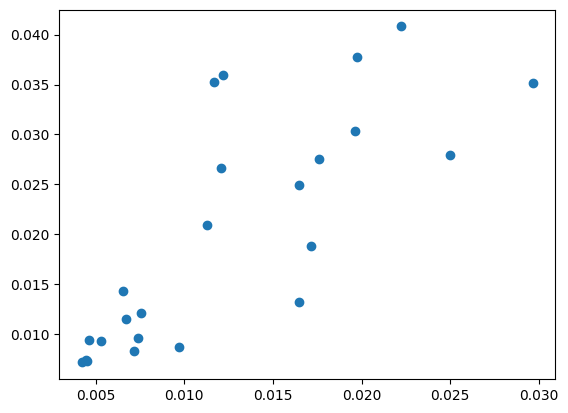

In [208]:
plt.scatter(heldout_abs_arr, abs_arr) 

(0.9884757104700393, 0.9728666695461777, 0.13877047547938848)

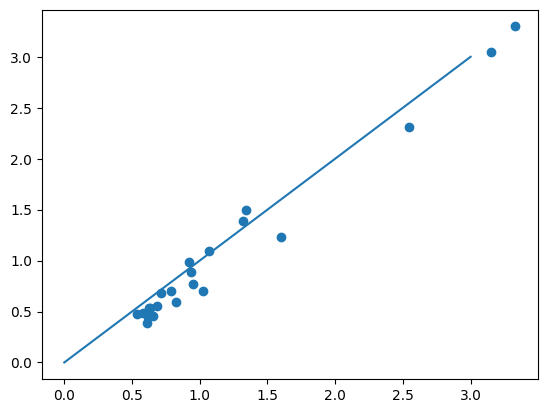

In [209]:
plt.plot(np.linspace(0, 3), np.linspace(0, 3))
plt.scatter(heldout_log_arr, log_arr) 

import scipy
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(log_arr, heldout_log_arr)
r_value, slope, intercept

In [18]:
df.sort_values(by="abs_error", ascending=True)[
    [
        "model_name",
        "proposal_idx_switch",
        "ablation_intensity",
        "proposal_bias",
        "abs_error",
        "mc_mean",
        "reweighted_scores",
        "judge_scores",
        "num_particles",
    ]
].head(10)


,model_name,proposal_idx_switch,ablation_intensity,proposal_bias,abs_error,mc_mean,reweighted_scores,judge_scores,num_particles
1,meta-llama/Llama-3.2-1B-Instruct,151,0.50,0.5,1.003840,0.042115,0.041954,0.335205,200
0,meta-llama/Llama-3.2-1B-Instruct,10,0.50,1.0,1.021118,0.042115,0.041244,0.388008,200
10,meta-llama/Llama-3.2-1B-Instruct,10,0.25,1.0,1.038039,0.042115,0.043717,0.216819,200
2,meta-llama/Llama-3.2-1B-Instruct,151,0.25,0.5,1.048722,0.042115,0.044167,0.163835,200
22,meta-llama/Llama-3.2-1B-Instruct,20,0.50,1.0,1.080283,0.042115,0.045496,0.469651,200
9,meta-llama/Llama-3.2-1B-Instruct,20,0.25,1.0,1.086878,0.042115,0.038748,0.237914,200
6,meta-llama/Llama-3.2-1B-Instruct,10,0.25,0.5,1.105727,0.042115,0.046567,0.136981,200
14,meta-llama/Llama-3.2-1B-Instruct,151,1.00,0.5,1.108097,0.042115,0.038006,0.411229,200
13,meta-llama/Llama-3.2-1B-Instruct,20,0.25,0.5,1.117567,0.042115,0.047066,0.144812,200
8,meta-llama/Llama-3.2-1B-Instruct,10,0.75,0.5,1.117833,0.042115,0.047077,0.282720,200


In [19]:
df.sort_values(by="abs_error", ascending=True)[
    [
        "model_name",
        "proposal_idx_switch",
        "ablation_intensity",
        "proposal_bias",
        "abs_error",
        "mc_mean",
        "reweighted_scores",
        "judge_scores",
        "num_particles",
    ]
].tail(10)

,model_name,proposal_idx_switch,ablation_intensity,proposal_bias,abs_error,mc_mean,reweighted_scores,judge_scores,num_particles
21,meta-llama/Llama-3.2-1B-Instruct,20,1.00,0.5,1.219392,0.042115,0.051354,0.325153,200
11,meta-llama/Llama-3.2-1B-Instruct,151,0.25,1.0,1.249075,0.042115,0.033717,0.295845,200
17,meta-llama/Llama-3.2-1B-Instruct,10,1.00,1.0,1.320300,0.042115,0.031898,0.436778,200
23,meta-llama/Llama-3.2-1B-Instruct,151,0.75,0.5,1.322460,0.042115,0.031846,0.403049,200
5,meta-llama/Llama-3.2-1B-Instruct,10,0.75,1.0,1.400480,0.042115,0.030072,0.430989,200
16,meta-llama/Llama-3.2-1B-Instruct,20,1.00,1.0,1.590633,0.042115,0.026477,0.543738,200
20,meta-llama/Llama-3.2-1B-Instruct,20,0.75,1.0,1.648653,0.042115,0.025545,0.535587,200
19,meta-llama/Llama-3.2-1B-Instruct,151,0.75,1.0,1.847134,0.042115,0.022800,0.700898,200
12,meta-llama/Llama-3.2-1B-Instruct,151,0.50,1.0,3.176721,0.042115,0.013257,0.612638,200
18,meta-llama/Llama-3.2-1B-Instruct,151,1.00,1.0,8.241017,0.042115,0.005110,0.710334,200


In [22]:
df.iloc[0]

seed                                                                                   42
max_new_tokens                                                                        150
output_dir                                                   grid_search_unsafe_to_unsafe
model_name                                               meta-llama/Llama-3.2-1B-Instruct
mc_est_dataset                          monte_carlo_estimates/results/strong_reject/Ll...
num_particles                                                                         200
fwd_batch_size                                                                        100
reward_batch_size                                                                      32
ablation_intensity                                                                    0.5
proposal_bias                                                                         1.0
proposal_idx_switch                                                                    10
use_smc   